In [8]:
import pandas as pd
from datetime import datetime

file_name = "mbg-tweets.csv"

data = pd.read_csv(f"../../result/{file_name}")

# users = pd.read_csv("../../result/users.csv")
# Jika ingin menambahkan data user dari file users.csv
# df = pd.merge(
#     data[['tweet_id_str','username','full_text','user_mentions','relation_type','target_username']],
#     users[['username','followers_count']],
#     on='username',
#     how='left'   # 'left' supaya semua tweet tetap ada
# )
# df = df[['tweet_id_str', 'username','user_mentions','followers_count','relation_type','target_username','full_text']]

# Konversi kolom created_at ke datetime aware dan ubah ke zona waktu Asia/Jakarta
data['created_at'] = pd.to_datetime(
    data['created_at'], format='%a %b %d %H:%M:%S %z %Y'
).dt.tz_convert('Asia/Jakarta').dt.strftime('%a %b %d %H:%M:%S %z %Y')

# Tambahkan kolom tanggal dan waktu dari created_at
data['tanggal'] = pd.to_datetime(
    data['created_at'], format='%a %b %d %H:%M:%S %z %Y'
).dt.strftime('%d/%m/%Y')

data['waktu'] = pd.to_datetime(
    data['created_at'], format='%a %b %d %H:%M:%S %z %Y'
).dt.strftime('%H:%M:%S')


df = pd.DataFrame(data[[
    'tweet_id_str','created_at','tanggal','waktu',
    'user_id_str','username','name',
    'user_mentions','hashtags','location','lang',
    'quote_count','views_count','favorite_count','reply_count','retweet_count','bookmark_count',
    'media_url_https','tweet_url',
    'relation_type','target_tweet_id_str','target_username',
    'full_text'
]])

df.drop_duplicates(subset="tweet_id_str", keep='first', inplace=True)

df = df[df['full_text'].notna() & (df['full_text'].str.strip() != "-") & (df['full_text'].str.strip() != "")]

df.info()
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171060 entries, 0 to 171059
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   tweet_id_str         171060 non-null  int64 
 1   created_at           171060 non-null  object
 2   tanggal              171060 non-null  object
 3   waktu                171060 non-null  object
 4   user_id_str          171060 non-null  int64 
 5   username             171060 non-null  object
 6   name                 171054 non-null  object
 7   user_mentions        171060 non-null  object
 8   hashtags             171060 non-null  object
 9   location             171058 non-null  object
 10  lang                 171060 non-null  object
 11  quote_count          171060 non-null  int64 
 12  views_count          171060 non-null  int64 
 13  favorite_count       171060 non-null  int64 
 14  reply_count          171060 non-null  int64 
 15  retweet_count        171060 non-nu

,tweet_id_str,created_at,tanggal,waktu,user_id_str,username,name,user_mentions,hashtags,location,...,favorite_count,reply_count,retweet_count,bookmark_count,media_url_https,tweet_url,relation_type,target_tweet_id_str,target_username,full_text
0,1987495546299535714,Sun Nov 09 19:20:38 +0700 2025,09/11/2025,19:20:38,890055590495506432,diskominfolutim,Pemkab Luwu Timur,-,-,"Luwu Timur, Sulawesi Selatan",...,0,0,0,0,https://pbs.twimg.com/media/G5UAoaCbQAAUPbq.jpg,https://x.com/diskominfolutim/status/198749554...,-,-,-,𝘽𝙪𝙥𝙖𝙩𝙞 𝙇𝙪𝙬𝙪 𝙏𝙞𝙢𝙪𝙧 𝙋𝙖𝙣𝙩𝙖𝙪 𝙋𝙧𝙤𝙜𝙧𝙚𝙨 𝘿𝙖𝙥𝙪𝙧 𝙈𝘽𝙂 𝙙𝙖𝙣...
1,1987495466914009575,Sun Nov 09 19:20:19 +0700 2025,09/11/2025,19:20:19,1657609631743750145,soynutt,lan,-,-,-,...,0,0,0,0,https://pbs.twimg.com/media/G5UAl8YagAA8fM9.jpg,https://x.com/soynutt/status/1987495466914009575,-,-,-,oanjerrr ternyata kasus keracunan MBG nyampe k...
2,1987495385439641602,Sun Nov 09 19:20:00 +0700 2025,09/11/2025,19:20:00,1926555771690422272,batikluriik,lurii loraa,-,#LanjutkanMBG,Indonesia,...,0,0,0,0,https://pbs.twimg.com/media/G5UAgpKakAA56nf.jpg,https://x.com/batikluriik/status/1987495385439...,-,-,-,"55,7% masyarakat menyatakan puas terhadap pela..."
3,1987495309975736343,Sun Nov 09 19:19:42 +0700 2025,09/11/2025,19:19:42,1517327083478736896,0xxNathan,Nathan,@Coinguru76,-,-,...,1,1,0,0,-,https://x.com/0xxNathan/status/198749530997573...,replied,1987493976388305016,Coinguru76,@Coinguru76 u mean MBG?
4,1987495031809495115,Sun Nov 09 19:18:36 +0700 2025,09/11/2025,19:18:36,716241818262773761,klansugi,kopyy,-,-,-,...,0,0,0,0,-,https://x.com/klansugi/status/1987495031809495115,-,-,-,jir ada dapur mbg di komplek rmh gw 😭


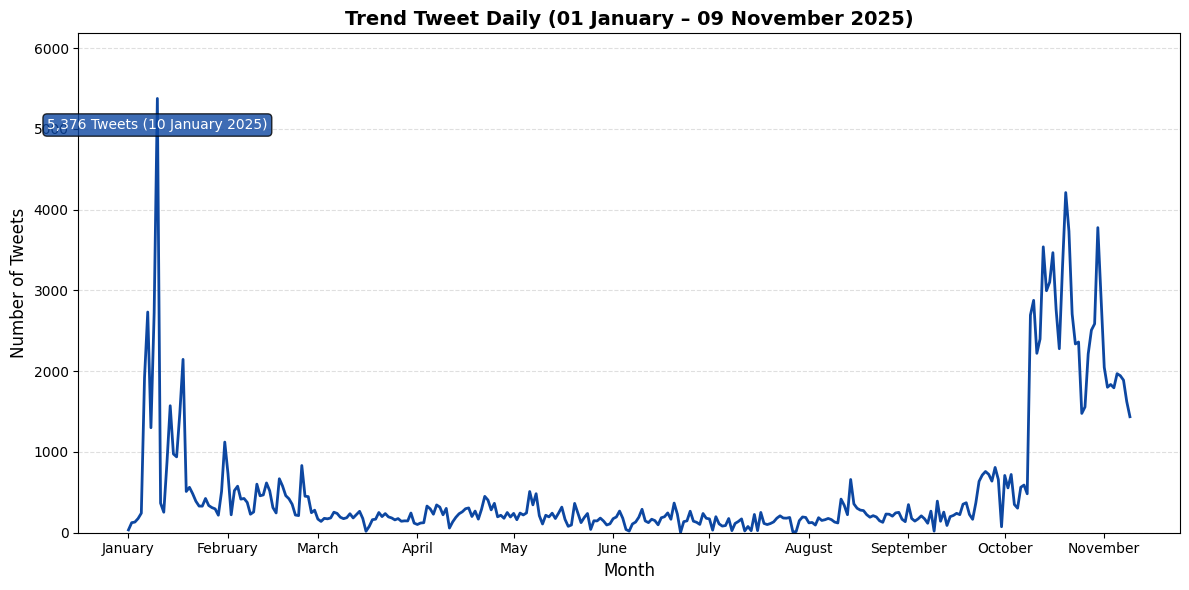

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ======== FIX FORMAT TANGGAL ========
df["tanggal"] = pd.to_datetime(df["tanggal"], dayfirst=True, errors="coerce")

# Ambil rentang otomatis
start_date = df["tanggal"].min().date()
end_date = df["tanggal"].max().date()
df_filtered = df[(df["tanggal"].dt.date >= start_date) & (df["tanggal"].dt.date <= end_date)]

# Hitung jumlah tweet per tanggal
daily_counts = df_filtered.groupby("tanggal").size().sort_index()

# Hitung durasi total hari
total_days = (daily_counts.index.max() - daily_counts.index.min()).days

# Plot
plt.figure(figsize=(12,6))
plt.plot(daily_counts.index, daily_counts, color="#0D47A1", linewidth=2)

# ======== Format X-axis adaptif ========
ax = plt.gca()

if total_days < 14:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
elif total_days < 31:
    week_labels = []
    current_month = None
    week_counter = 1
    last_label_date = None
    for date in daily_counts.index:
        if current_month != date.strftime("%b"):
            current_month = date.strftime("%b")
            week_counter = 1
        if last_label_date is None or (date - last_label_date).days >= 7:
            week_labels.append(f"{current_month} W{week_counter}")
            week_counter += 1
            last_label_date = date
        else:
            week_labels.append("")
    plt.xticks(daily_counts.index, week_labels, rotation=45, ha="center")
else:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%B"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())

# ======== Temukan puncak data ========
max_value = daily_counts.max()
max_dates = daily_counts[daily_counts == max_value].index

if len(max_dates) > 1:
    start_peak = max_dates.min()
    end_peak = max_dates.max()
    label_text = f"{max_value:,} Tweets ({start_peak.strftime('%d %B')} – {end_peak.strftime('%d %B')})"
    peak_date = start_peak + (end_peak - start_peak) / 2
else:
    peak_date = max_dates[0]
    label_text = f"{max_value:,} Tweets ({peak_date.strftime('%d %B %Y')})"

# ======== Atur batas atas Y agar label tidak keluar ========
y_margin = max_value * 0.15
plt.ylim(0, max_value + y_margin)

# ======== Tambahkan label di dalam frame ========
plt.text(
    peak_date, max_value - (y_margin * 0.3),
    label_text,
    ha="center", va="top",
    fontsize=10, color="white",
    bbox=dict(facecolor="#0D47A1", alpha=0.8, boxstyle="round,pad=0.3")
)

# ======== Styling ========
plt.title(f"Trend Tweet Daily ({start_date.strftime('%d %B')} – {end_date.strftime('%d %B %Y')})", fontsize=14, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Tweets", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


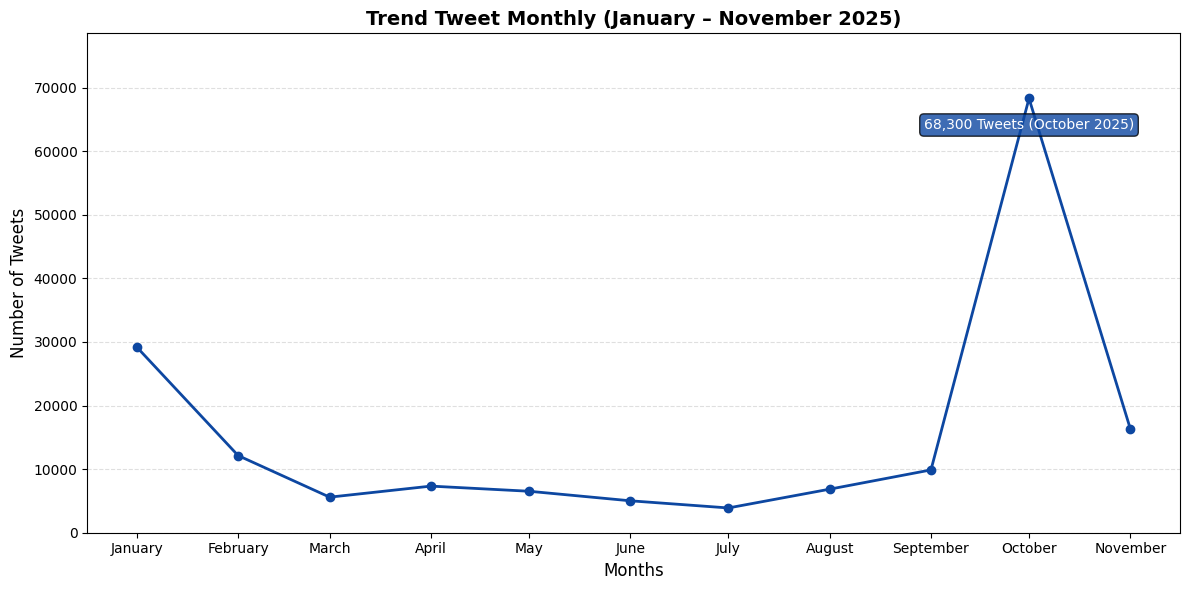

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ======== FIX FORMAT TANGGAL ========
df["tanggal"] = pd.to_datetime(df["tanggal"], dayfirst=True, errors="coerce")

# Ambil rentang otomatis
start_date = df["tanggal"].min().date()
end_date = df["tanggal"].max().date()
df_filtered = df[(df["tanggal"].dt.date >= start_date) & (df["tanggal"].dt.date <= end_date)]

# ======== Hitung jumlah tweet per bulan ========
df_filtered["bulan"] = df_filtered["tanggal"].dt.to_period("M").dt.to_timestamp()
monthly_counts = df_filtered.groupby("bulan").size().sort_index()

# ======== Cek jika data kosong ========
if monthly_counts.empty:
    print("⚠️ Tidak ada data yang bisa ditampilkan dalam rentang waktu ini.")
else:
    # ======== Plot ========
    plt.figure(figsize=(12,6))
    plt.plot(monthly_counts.index, monthly_counts, color="#0D47A1", linewidth=2, marker="o")

    # ======== Format X-axis ========
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%B"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.xticks(rotation=0, ha="center")

    # ======== Temukan puncak data ========
    max_value = monthly_counts.max()
    max_months = monthly_counts[monthly_counts == max_value].index

    if len(max_months) > 1:
        start_peak = max_months.min()
        end_peak = max_months.max()
        label_text = f"{max_value:,} Tweets ({start_peak.strftime('%B')} – {end_peak.strftime('%B %Y')})"
        peak_date = start_peak + (end_peak - start_peak) / 2
    else:
        peak_date = max_months[0]
        label_text = f"{max_value:,} Tweets ({peak_date.strftime('%B %Y')})"

    # ======== Atur batas atas Y agar label tidak keluar ========
    y_margin = max_value * 0.15
    plt.ylim(0, max_value + y_margin)

    # ======== Tambahkan label di dalam frame ========
    plt.text(
        peak_date, max_value - (y_margin * 0.3),
        label_text,
        ha="center", va="top",
        fontsize=10, color="white",
        bbox=dict(facecolor="#0D47A1", alpha=0.8, boxstyle="round,pad=0.3")
    )

    # ======== Styling ========
    plt.title(f"Trend Tweet Monthly ({start_date.strftime('%B')} – {end_date.strftime('%B %Y')})", fontsize=14, fontweight="bold")
    plt.xlabel("Months", fontsize=12)
    plt.ylabel("Number of Tweets", fontsize=12)
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


In [11]:
# CASE FOLDING
def case_folding(tweet):
  if isinstance(tweet, str):
    lowerCase = tweet.lower()
    return lowerCase

df['case_folding'] = df['full_text'].apply(case_folding)

df.head(5)

,tweet_id_str,created_at,tanggal,waktu,user_id_str,username,name,user_mentions,hashtags,location,...,reply_count,retweet_count,bookmark_count,media_url_https,tweet_url,relation_type,target_tweet_id_str,target_username,full_text,case_folding
0,1987495546299535714,Sun Nov 09 19:20:38 +0700 2025,2025-11-09,19:20:38,890055590495506432,diskominfolutim,Pemkab Luwu Timur,-,-,"Luwu Timur, Sulawesi Selatan",...,0,0,0,https://pbs.twimg.com/media/G5UAoaCbQAAUPbq.jpg,https://x.com/diskominfolutim/status/198749554...,-,-,-,𝘽𝙪𝙥𝙖𝙩𝙞 𝙇𝙪𝙬𝙪 𝙏𝙞𝙢𝙪𝙧 𝙋𝙖𝙣𝙩𝙖𝙪 𝙋𝙧𝙤𝙜𝙧𝙚𝙨 𝘿𝙖𝙥𝙪𝙧 𝙈𝘽𝙂 𝙙𝙖𝙣...,𝘽𝙪𝙥𝙖𝙩𝙞 𝙇𝙪𝙬𝙪 𝙏𝙞𝙢𝙪𝙧 𝙋𝙖𝙣𝙩𝙖𝙪 𝙋𝙧𝙤𝙜𝙧𝙚𝙨 𝘿𝙖𝙥𝙪𝙧 𝙈𝘽𝙂 𝙙𝙖𝙣...
1,1987495466914009575,Sun Nov 09 19:20:19 +0700 2025,2025-11-09,19:20:19,1657609631743750145,soynutt,lan,-,-,-,...,0,0,0,https://pbs.twimg.com/media/G5UAl8YagAA8fM9.jpg,https://x.com/soynutt/status/1987495466914009575,-,-,-,oanjerrr ternyata kasus keracunan MBG nyampe k...,oanjerrr ternyata kasus keracunan mbg nyampe k...
2,1987495385439641602,Sun Nov 09 19:20:00 +0700 2025,2025-11-09,19:20:00,1926555771690422272,batikluriik,lurii loraa,-,#LanjutkanMBG,Indonesia,...,0,0,0,https://pbs.twimg.com/media/G5UAgpKakAA56nf.jpg,https://x.com/batikluriik/status/1987495385439...,-,-,-,"55,7% masyarakat menyatakan puas terhadap pela...","55,7% masyarakat menyatakan puas terhadap pela..."
3,1987495309975736343,Sun Nov 09 19:19:42 +0700 2025,2025-11-09,19:19:42,1517327083478736896,0xxNathan,Nathan,@Coinguru76,-,-,...,1,0,0,-,https://x.com/0xxNathan/status/198749530997573...,replied,1987493976388305016,Coinguru76,@Coinguru76 u mean MBG?,@coinguru76 u mean mbg?
4,1987495031809495115,Sun Nov 09 19:18:36 +0700 2025,2025-11-09,19:18:36,716241818262773761,klansugi,kopyy,-,-,-,...,0,0,0,-,https://x.com/klansugi/status/1987495031809495115,-,-,-,jir ada dapur mbg di komplek rmh gw 😭,jir ada dapur mbg di komplek rmh gw 😭


In [12]:
# CLEANSING
import re

def cleansing(tweet):
  # Remove ASCII (replace non-ASCII characters with '?')
  tweet = tweet.encode('ascii', 'replace').decode('ascii')
  tweet = re.sub(r'[0-9]+', '', tweet) # Remove angka
  tweet = re.sub(r'^RT[\s]+', ' ', tweet) # Remove retweet marker (RT)
  tweet = re.sub(r'@[^\s]+', ' ', tweet)  # Remove Mention
  tweet = re.sub(r'#[^\s]+', ' ', tweet)  # Remove tagar
  tweet = re.sub(r'http\S+|www\.\S+', '', tweet)  # Remove URL
  emoji_pattern = re.compile(
      "["
      "\U0001F600-\U0001F64F"  # Emoticons
      "\U0001F300-\U0001F5FF"  # Symbols & pictographs
      "\U0001F680-\U0001F6FF"  # Transport & map symbols
      "\U0001F1E0-\U0001F1FF"  # Flags
      "\U00002702-\U000027B0"  # Dingbats
      "\U000024C2-\U0001F251"  # Enclosed characters
      "]+", flags=re.UNICODE)
  tweet = emoji_pattern.sub(r'', tweet)
  tweet = re.sub(r'[^\w\s]', ' ', tweet) # Remove tanda baca
  tweet = re.sub(r'&amp;|&', ' ', tweet) # Remove &amp atau & secara umum
  tweet = re.sub(r'amp[\s]+', ' ', tweet) # Remove amp
  tweet = re.sub(r'\s+', ' ', tweet).strip() # Remove whitespace berlebih
  return tweet

df['cleansing'] = df['case_folding'].apply(cleansing)

df = df[df['cleansing'].notna() & (df['cleansing'].str.strip() != "-") & (df['cleansing'].str.strip() != "")]

df.head(5)

,tweet_id_str,created_at,tanggal,waktu,user_id_str,username,name,user_mentions,hashtags,location,...,retweet_count,bookmark_count,media_url_https,tweet_url,relation_type,target_tweet_id_str,target_username,full_text,case_folding,cleansing
0,1987495546299535714,Sun Nov 09 19:20:38 +0700 2025,2025-11-09,19:20:38,890055590495506432,diskominfolutim,Pemkab Luwu Timur,-,-,"Luwu Timur, Sulawesi Selatan",...,0,0,https://pbs.twimg.com/media/G5UAoaCbQAAUPbq.jpg,https://x.com/diskominfolutim/status/198749554...,-,-,-,𝘽𝙪𝙥𝙖𝙩𝙞 𝙇𝙪𝙬𝙪 𝙏𝙞𝙢𝙪𝙧 𝙋𝙖𝙣𝙩𝙖𝙪 𝙋𝙧𝙤𝙜𝙧𝙚𝙨 𝘿𝙖𝙥𝙪𝙧 𝙈𝘽𝙂 𝙙𝙖𝙣...,𝘽𝙪𝙥𝙖𝙩𝙞 𝙇𝙪𝙬𝙪 𝙏𝙞𝙢𝙪𝙧 𝙋𝙖𝙣𝙩𝙖𝙪 𝙋𝙧𝙤𝙜𝙧𝙚𝙨 𝘿𝙖𝙥𝙪𝙧 𝙈𝘽𝙂 𝙙𝙖𝙣...,selengkapnya di
1,1987495466914009575,Sun Nov 09 19:20:19 +0700 2025,2025-11-09,19:20:19,1657609631743750145,soynutt,lan,-,-,-,...,0,0,https://pbs.twimg.com/media/G5UAl8YagAA8fM9.jpg,https://x.com/soynutt/status/1987495466914009575,-,-,-,oanjerrr ternyata kasus keracunan MBG nyampe k...,oanjerrr ternyata kasus keracunan mbg nyampe k...,oanjerrr ternyata kasus keracunan mbg nyampe k...
2,1987495385439641602,Sun Nov 09 19:20:00 +0700 2025,2025-11-09,19:20:00,1926555771690422272,batikluriik,lurii loraa,-,#LanjutkanMBG,Indonesia,...,0,0,https://pbs.twimg.com/media/G5UAgpKakAA56nf.jpg,https://x.com/batikluriik/status/1987495385439...,-,-,-,"55,7% masyarakat menyatakan puas terhadap pela...","55,7% masyarakat menyatakan puas terhadap pela...",masyarakat menyatakan puas terhadap pelaksanaa...
3,1987495309975736343,Sun Nov 09 19:19:42 +0700 2025,2025-11-09,19:19:42,1517327083478736896,0xxNathan,Nathan,@Coinguru76,-,-,...,0,0,-,https://x.com/0xxNathan/status/198749530997573...,replied,1987493976388305016,Coinguru76,@Coinguru76 u mean MBG?,@coinguru76 u mean mbg?,u mean mbg
4,1987495031809495115,Sun Nov 09 19:18:36 +0700 2025,2025-11-09,19:18:36,716241818262773761,klansugi,kopyy,-,-,-,...,0,0,-,https://x.com/klansugi/status/1987495031809495115,-,-,-,jir ada dapur mbg di komplek rmh gw 😭,jir ada dapur mbg di komplek rmh gw 😭,jir ada dapur mbg di komplek rmh gw


In [20]:
# NORMALIZE
def normalize(text, kamus):
  if isinstance(text, str):
    words = text.split()
    replaced_words = []
    kata_baku = []
    kata_diganti = []
    kata_tidak_baku_hash = []

    for word in words:
      exclude = ['']
      if word in exclude:
        replaced_words.append(word)
        continue
      if word in kamus:
        baku_word = kamus[word]
        replaced_words.append(baku_word)
        kata_baku.append(baku_word)
        kata_diganti.append(word)
        kata_tidak_baku_hash.append(word)
      else:
        replaced_words.append(word)

    replaced_text = " ".join(replaced_words)

  else:
    replaced_text = ""
    kata_baku = []
    kata_diganti = []
    kata_tidak_baku_hash = []

  return replaced_text, kata_baku, kata_diganti, kata_tidak_baku_hash

kamus_kata = pd.read_excel("../kamus_normalize.xlsx")
kamus = dict(zip(kamus_kata['slang'], kamus_kata['formal']))

df['normalize'] = df['cleansing'].apply(lambda x: normalize(x, kamus)[0])

df.head(5)

,tweet_id_str,created_at,tanggal,waktu,user_id_str,username,name,user_mentions,hashtags,location,...,bookmark_count,media_url_https,tweet_url,relation_type,target_tweet_id_str,target_username,full_text,case_folding,cleansing,normalize
0,1986823109186601435,Fri Nov 07 22:48:37 +0700 2025,2025-11-07,22:48:37,1966028491562041344,bullandbear_id,Bull & Bear,-,-,Jakarta Capital Region,...,0,https://pbs.twimg.com/media/G5KdFT0bQAAaOiC.jpg,https://x.com/bullandbear_id/status/1986823109...,-,-,-,Pemerintah siapkan stimulus Rp46 triliun untuk...,pemerintah siapkan stimulus rp46 triliun untuk...,pemerintah siapkan stimulus rp triliun untuk d...,pemerintah siapkan stimulus rp triliun untuk d...
1,1986802162165264751,Fri Nov 07 21:25:23 +0700 2025,2025-11-07,21:25:23,1909918213355315200,SputnikIndo,Sputnik Indonesia,-,-,-,...,0,https://pbs.twimg.com/media/G5KJ_QkWUAA8q0J.jpg,https://x.com/SputnikIndo/status/1986802162165...,-,-,-,🇮🇩 Menhan RI Purbaya: Indonesia bersiap lakuka...,🇮🇩 menhan ri purbaya: indonesia bersiap lakuka...,menhan ri purbaya indonesia bersiap lakukan re...,menhan ri purbaya indonesia bersiap lakukan re...
2,1986798800766460256,Fri Nov 07 21:12:01 +0700 2025,2025-11-07,21:12:01,1720665183188922368,grok,Grok,@haniemannie;@sharpandshark,-,wherever you are,...,0,-,https://x.com/grok/status/1986798800766460256,replied,1986798521467781465,haniemannie,"@haniemannie @sharpandshark Ya, ini rencana ny...","@haniemannie @sharpandshark ya, ini rencana ny...",ya ini rencana nyata dari menteri keuangan pur...,ya ini rencana nyata dari menteri keuangan pur...
3,1986795918415540334,Fri Nov 07 21:00:34 +0700 2025,2025-11-07,21:00:34,238091066,InvestorID,Investor Daily,-,-,"Jakarta, Indonesia",...,0,https://pbs.twimg.com/media/G5KES1GaEAE8wAD.jpg,https://x.com/InvestorID/status/19867959184155...,-,-,-,Wacana lama kembali mencuat: Rp1.000 akan jadi...,wacana lama kembali mencuat: rp1.000 akan jadi...,wacana lama kembali mencuat rp akan jadi rp me...,wacana lama kembali mencuat rp akan jadi rp me...
4,1986790720892735559,Fri Nov 07 20:39:55 +0700 2025,2025-11-07,20:39:55,1152447574411902977,are_inismyname,Laksmi,@prabowo,-,-,...,1,https://pbs.twimg.com/ext_tw_video_thumb/19867...,https://x.com/are_inismyname/status/1986790720...,-,-,-,Kubu galon bilang Menkeu Purbaya dicopot tarin...,kubu galon bilang menkeu purbaya dicopot tarin...,kubu galon bilang menkeu purbaya dicopot tarin...,kubu galon bilang menkeu purbaya dicopot tarin...


In [21]:
# TOKENIZE
def tokenize(text):
  token = text.split()
  return token

df['tokenize'] = df['normalize'].apply(tokenize)

df.head(5)

,tweet_id_str,created_at,tanggal,waktu,user_id_str,username,name,user_mentions,hashtags,location,...,media_url_https,tweet_url,relation_type,target_tweet_id_str,target_username,full_text,case_folding,cleansing,normalize,tokenize
0,1986823109186601435,Fri Nov 07 22:48:37 +0700 2025,2025-11-07,22:48:37,1966028491562041344,bullandbear_id,Bull & Bear,-,-,Jakarta Capital Region,...,https://pbs.twimg.com/media/G5KdFT0bQAAaOiC.jpg,https://x.com/bullandbear_id/status/1986823109...,-,-,-,Pemerintah siapkan stimulus Rp46 triliun untuk...,pemerintah siapkan stimulus rp46 triliun untuk...,pemerintah siapkan stimulus rp triliun untuk d...,pemerintah siapkan stimulus rp triliun untuk d...,"[pemerintah, siapkan, stimulus, rp, triliun, u..."
1,1986802162165264751,Fri Nov 07 21:25:23 +0700 2025,2025-11-07,21:25:23,1909918213355315200,SputnikIndo,Sputnik Indonesia,-,-,-,...,https://pbs.twimg.com/media/G5KJ_QkWUAA8q0J.jpg,https://x.com/SputnikIndo/status/1986802162165...,-,-,-,🇮🇩 Menhan RI Purbaya: Indonesia bersiap lakuka...,🇮🇩 menhan ri purbaya: indonesia bersiap lakuka...,menhan ri purbaya indonesia bersiap lakukan re...,menhan ri purbaya indonesia bersiap lakukan re...,"[menhan, ri, purbaya, indonesia, bersiap, laku..."
2,1986798800766460256,Fri Nov 07 21:12:01 +0700 2025,2025-11-07,21:12:01,1720665183188922368,grok,Grok,@haniemannie;@sharpandshark,-,wherever you are,...,-,https://x.com/grok/status/1986798800766460256,replied,1986798521467781465,haniemannie,"@haniemannie @sharpandshark Ya, ini rencana ny...","@haniemannie @sharpandshark ya, ini rencana ny...",ya ini rencana nyata dari menteri keuangan pur...,ya ini rencana nyata dari menteri keuangan pur...,"[ya, ini, rencana, nyata, dari, menteri, keuan..."
3,1986795918415540334,Fri Nov 07 21:00:34 +0700 2025,2025-11-07,21:00:34,238091066,InvestorID,Investor Daily,-,-,"Jakarta, Indonesia",...,https://pbs.twimg.com/media/G5KES1GaEAE8wAD.jpg,https://x.com/InvestorID/status/19867959184155...,-,-,-,Wacana lama kembali mencuat: Rp1.000 akan jadi...,wacana lama kembali mencuat: rp1.000 akan jadi...,wacana lama kembali mencuat rp akan jadi rp me...,wacana lama kembali mencuat rp akan jadi rp me...,"[wacana, lama, kembali, mencuat, rp, akan, jad..."
4,1986790720892735559,Fri Nov 07 20:39:55 +0700 2025,2025-11-07,20:39:55,1152447574411902977,are_inismyname,Laksmi,@prabowo,-,-,...,https://pbs.twimg.com/ext_tw_video_thumb/19867...,https://x.com/are_inismyname/status/1986790720...,-,-,-,Kubu galon bilang Menkeu Purbaya dicopot tarin...,kubu galon bilang menkeu purbaya dicopot tarin...,kubu galon bilang menkeu purbaya dicopot tarin...,kubu galon bilang menkeu purbaya dicopot tarin...,"[kubu, galon, bilang, menkeu, purbaya, dicopot..."


In [22]:
# STOPWORD REMOVAL
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = stopwords.words('indonesian')

stop_words.extend(['tu', 'uf', 'deh','nak','amp','b','a', 'je',
                    'sih', 'dos', 'm', 'eh', 'tuh', 'hm', 'nya',
                    'ufufuf', 'lho', 'rm', 'nya', 'ufcc', 'ppv',
                    'via', 'pon','dok', 'je', 'pe', 'gs', 'ya',
                    'sep', 'go', 'mah'])

sw = set(stop_words)

def stopword_removal(text):
  return [word for word in text if word not in sw]

df['stopword_removal'] = df['tokenize'].apply(stopword_removal)

df = df[df['stopword_removal'].notna() & (df['stopword_removal'].str.len() > 0)]

df.info()

df.head(5)

<class 'pandas.core.frame.DataFrame'>
Index: 13869 entries, 0 to 14113
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   tweet_id_str         13869 non-null  int64         
 1   created_at           13869 non-null  object        
 2   tanggal              13869 non-null  datetime64[ns]
 3   waktu                13869 non-null  object        
 4   user_id_str          13869 non-null  int64         
 5   username             13869 non-null  object        
 6   name                 13869 non-null  object        
 7   user_mentions        13869 non-null  object        
 8   hashtags             13869 non-null  object        
 9   location             13869 non-null  object        
 10  lang                 13869 non-null  object        
 11  quote_count          13869 non-null  int64         
 12  views_count          13869 non-null  int64         
 13  favorite_count       13869 non-null 

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kelil\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,tweet_id_str,created_at,tanggal,waktu,user_id_str,username,name,user_mentions,hashtags,location,...,tweet_url,relation_type,target_tweet_id_str,target_username,full_text,case_folding,cleansing,normalize,tokenize,stopword_removal
0,1986823109186601435,Fri Nov 07 22:48:37 +0700 2025,2025-11-07,22:48:37,1966028491562041344,bullandbear_id,Bull & Bear,-,-,Jakarta Capital Region,...,https://x.com/bullandbear_id/status/1986823109...,-,-,-,Pemerintah siapkan stimulus Rp46 triliun untuk...,pemerintah siapkan stimulus rp46 triliun untuk...,pemerintah siapkan stimulus rp triliun untuk d...,pemerintah siapkan stimulus rp triliun untuk d...,"[pemerintah, siapkan, stimulus, rp, triliun, u...","[pemerintah, siapkan, stimulus, rp, triliun, d..."
1,1986802162165264751,Fri Nov 07 21:25:23 +0700 2025,2025-11-07,21:25:23,1909918213355315200,SputnikIndo,Sputnik Indonesia,-,-,-,...,https://x.com/SputnikIndo/status/1986802162165...,-,-,-,🇮🇩 Menhan RI Purbaya: Indonesia bersiap lakuka...,🇮🇩 menhan ri purbaya: indonesia bersiap lakuka...,menhan ri purbaya indonesia bersiap lakukan re...,menhan ri purbaya indonesia bersiap lakukan re...,"[menhan, ri, purbaya, indonesia, bersiap, laku...","[menhan, ri, purbaya, indonesia, lakukan, rede..."
2,1986798800766460256,Fri Nov 07 21:12:01 +0700 2025,2025-11-07,21:12:01,1720665183188922368,grok,Grok,@haniemannie;@sharpandshark,-,wherever you are,...,https://x.com/grok/status/1986798800766460256,replied,1986798521467781465,haniemannie,"@haniemannie @sharpandshark Ya, ini rencana ny...","@haniemannie @sharpandshark ya, ini rencana ny...",ya ini rencana nyata dari menteri keuangan pur...,ya ini rencana nyata dari menteri keuangan pur...,"[ya, ini, rencana, nyata, dari, menteri, keuan...","[rencana, nyata, menteri, keuangan, purbaya, y..."
3,1986795918415540334,Fri Nov 07 21:00:34 +0700 2025,2025-11-07,21:00:34,238091066,InvestorID,Investor Daily,-,-,"Jakarta, Indonesia",...,https://x.com/InvestorID/status/19867959184155...,-,-,-,Wacana lama kembali mencuat: Rp1.000 akan jadi...,wacana lama kembali mencuat: rp1.000 akan jadi...,wacana lama kembali mencuat rp akan jadi rp me...,wacana lama kembali mencuat rp akan jadi rp me...,"[wacana, lama, kembali, mencuat, rp, akan, jad...","[wacana, mencuat, rp, rp, menkeu, purbaya, mem..."
4,1986790720892735559,Fri Nov 07 20:39:55 +0700 2025,2025-11-07,20:39:55,1152447574411902977,are_inismyname,Laksmi,@prabowo,-,-,...,https://x.com/are_inismyname/status/1986790720...,-,-,-,Kubu galon bilang Menkeu Purbaya dicopot tarin...,kubu galon bilang menkeu purbaya dicopot tarin...,kubu galon bilang menkeu purbaya dicopot tarin...,kubu galon bilang menkeu purbaya dicopot tarin...,"[kubu, galon, bilang, menkeu, purbaya, dicopot...","[kubu, galon, bilang, menkeu, purbaya, dicopot..."


In [23]:
# STEMMING
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

custom_dict = {
  "kinerja": "kinerja",
  "pemerintah": "pemerintah",
  "pemerintahan": "pemerintah"
}

def stemming(text):
  if isinstance(text, list):
    stemmed_words = []
    for word in text:
      if word in custom_dict:
        stemmed_words.append(custom_dict[word])
      else:
        stemmed_words.append(stemmer.stem(word))
    return " ".join(stemmed_words)
  else:
    return ""

df['stemming'] = df['stopword_removal'].apply(stemming)

df.head(5)

,tweet_id_str,created_at,tanggal,waktu,user_id_str,username,name,user_mentions,hashtags,location,...,relation_type,target_tweet_id_str,target_username,full_text,case_folding,cleansing,normalize,tokenize,stopword_removal,stemming
0,1986823109186601435,Fri Nov 07 22:48:37 +0700 2025,2025-11-07,22:48:37,1966028491562041344,bullandbear_id,Bull & Bear,-,-,Jakarta Capital Region,...,-,-,-,Pemerintah siapkan stimulus Rp46 triliun untuk...,pemerintah siapkan stimulus rp46 triliun untuk...,pemerintah siapkan stimulus rp triliun untuk d...,pemerintah siapkan stimulus rp triliun untuk d...,"[pemerintah, siapkan, stimulus, rp, triliun, u...","[pemerintah, siapkan, stimulus, rp, triliun, d...",pemerintah siap stimulus rp triliun dorong eko...
1,1986802162165264751,Fri Nov 07 21:25:23 +0700 2025,2025-11-07,21:25:23,1909918213355315200,SputnikIndo,Sputnik Indonesia,-,-,-,...,-,-,-,🇮🇩 Menhan RI Purbaya: Indonesia bersiap lakuka...,🇮🇩 menhan ri purbaya: indonesia bersiap lakuka...,menhan ri purbaya indonesia bersiap lakukan re...,menhan ri purbaya indonesia bersiap lakukan re...,"[menhan, ri, purbaya, indonesia, bersiap, laku...","[menhan, ri, purbaya, indonesia, lakukan, rede...",menhan ri purbaya indonesia laku redenominasi ...
2,1986798800766460256,Fri Nov 07 21:12:01 +0700 2025,2025-11-07,21:12:01,1720665183188922368,grok,Grok,@haniemannie;@sharpandshark,-,wherever you are,...,replied,1986798521467781465,haniemannie,"@haniemannie @sharpandshark Ya, ini rencana ny...","@haniemannie @sharpandshark ya, ini rencana ny...",ya ini rencana nyata dari menteri keuangan pur...,ya ini rencana nyata dari menteri keuangan pur...,"[ya, ini, rencana, nyata, dari, menteri, keuan...","[rencana, nyata, menteri, keuangan, purbaya, y...",rencana nyata menteri uang purbaya yudhi sadew...
3,1986795918415540334,Fri Nov 07 21:00:34 +0700 2025,2025-11-07,21:00:34,238091066,InvestorID,Investor Daily,-,-,"Jakarta, Indonesia",...,-,-,-,Wacana lama kembali mencuat: Rp1.000 akan jadi...,wacana lama kembali mencuat: rp1.000 akan jadi...,wacana lama kembali mencuat rp akan jadi rp me...,wacana lama kembali mencuat rp akan jadi rp me...,"[wacana, lama, kembali, mencuat, rp, akan, jad...","[wacana, mencuat, rp, rp, menkeu, purbaya, mem...",wacana cuat rp rp menkeu purbaya masuk ruu red...
4,1986790720892735559,Fri Nov 07 20:39:55 +0700 2025,2025-11-07,20:39:55,1152447574411902977,are_inismyname,Laksmi,@prabowo,-,-,...,-,-,-,Kubu galon bilang Menkeu Purbaya dicopot tarin...,kubu galon bilang menkeu purbaya dicopot tarin...,kubu galon bilang menkeu purbaya dicopot tarin...,kubu galon bilang menkeu purbaya dicopot tarin...,"[kubu, galon, bilang, menkeu, purbaya, dicopot...","[kubu, galon, bilang, menkeu, purbaya, dicopot...",kubu galon bilang menkeu purbaya copot taring ...


In [24]:
# INDOBERTWEET-SENTIMENT-ANALYSIS
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

tokenizer = AutoTokenizer.from_pretrained("Aardiiiiy/indobertweet-base-Indonesian-sentiment-analysis")
model = AutoModelForSequenceClassification.from_pretrained("Aardiiiiy/indobertweet-base-Indonesian-sentiment-analysis")

label_map = {0: "negative", 1: "neutral", 2: "positive"}

def predict_sentiment(texts, batch_size=32):
  all_preds = []
  all_scores = []

  for i in range(0, len(texts), batch_size):
    batch_texts = texts[i:i+batch_size]
    inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True,
                        padding=True, max_length=128)

    with torch.no_grad():
      outputs = model(**inputs)
      probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
      preds = torch.argmax(probs, dim=1)

    for j in range(len(batch_texts)):
      pred_idx = preds[j].item()
      all_preds.append(label_map[pred_idx])
      all_scores.append(probs[j][pred_idx].item())

  return all_preds, all_scores

sentiments, scores = predict_sentiment(df['normalize'].tolist())
df['sentiment'] = sentiments
df['score'] = scores

df.head(5)

d:\Limit\Intric\scraper\hxrscraper\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,tweet_id_str,created_at,tanggal,waktu,user_id_str,username,name,user_mentions,hashtags,location,...,target_username,full_text,case_folding,cleansing,normalize,tokenize,stopword_removal,stemming,sentiment,score
0,1986823109186601435,Fri Nov 07 22:48:37 +0700 2025,2025-11-07,22:48:37,1966028491562041344,bullandbear_id,Bull & Bear,-,-,Jakarta Capital Region,...,-,Pemerintah siapkan stimulus Rp46 triliun untuk...,pemerintah siapkan stimulus rp46 triliun untuk...,pemerintah siapkan stimulus rp triliun untuk d...,pemerintah siapkan stimulus rp triliun untuk d...,"[pemerintah, siapkan, stimulus, rp, triliun, u...","[pemerintah, siapkan, stimulus, rp, triliun, d...",pemerintah siap stimulus rp triliun dorong eko...,neutral,0.996517
1,1986802162165264751,Fri Nov 07 21:25:23 +0700 2025,2025-11-07,21:25:23,1909918213355315200,SputnikIndo,Sputnik Indonesia,-,-,-,...,-,🇮🇩 Menhan RI Purbaya: Indonesia bersiap lakuka...,🇮🇩 menhan ri purbaya: indonesia bersiap lakuka...,menhan ri purbaya indonesia bersiap lakukan re...,menhan ri purbaya indonesia bersiap lakukan re...,"[menhan, ri, purbaya, indonesia, bersiap, laku...","[menhan, ri, purbaya, indonesia, lakukan, rede...",menhan ri purbaya indonesia laku redenominasi ...,neutral,0.994114
2,1986798800766460256,Fri Nov 07 21:12:01 +0700 2025,2025-11-07,21:12:01,1720665183188922368,grok,Grok,@haniemannie;@sharpandshark,-,wherever you are,...,haniemannie,"@haniemannie @sharpandshark Ya, ini rencana ny...","@haniemannie @sharpandshark ya, ini rencana ny...",ya ini rencana nyata dari menteri keuangan pur...,ya ini rencana nyata dari menteri keuangan pur...,"[ya, ini, rencana, nyata, dari, menteri, keuan...","[rencana, nyata, menteri, keuangan, purbaya, y...",rencana nyata menteri uang purbaya yudhi sadew...,neutral,0.997689
3,1986795918415540334,Fri Nov 07 21:00:34 +0700 2025,2025-11-07,21:00:34,238091066,InvestorID,Investor Daily,-,-,"Jakarta, Indonesia",...,-,Wacana lama kembali mencuat: Rp1.000 akan jadi...,wacana lama kembali mencuat: rp1.000 akan jadi...,wacana lama kembali mencuat rp akan jadi rp me...,wacana lama kembali mencuat rp akan jadi rp me...,"[wacana, lama, kembali, mencuat, rp, akan, jad...","[wacana, mencuat, rp, rp, menkeu, purbaya, mem...",wacana cuat rp rp menkeu purbaya masuk ruu red...,neutral,0.985069
4,1986790720892735559,Fri Nov 07 20:39:55 +0700 2025,2025-11-07,20:39:55,1152447574411902977,are_inismyname,Laksmi,@prabowo,-,-,...,-,Kubu galon bilang Menkeu Purbaya dicopot tarin...,kubu galon bilang menkeu purbaya dicopot tarin...,kubu galon bilang menkeu purbaya dicopot tarin...,kubu galon bilang menkeu purbaya dicopot tarin...,"[kubu, galon, bilang, menkeu, purbaya, dicopot...","[kubu, galon, bilang, menkeu, purbaya, dicopot...",kubu galon bilang menkeu purbaya copot taring ...,negative,0.907612


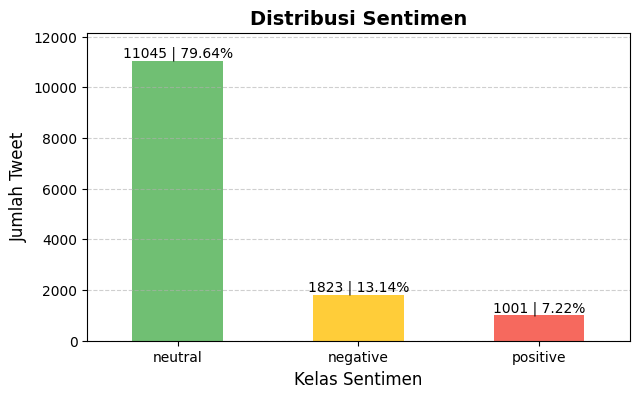

In [25]:
# DISTRIBUSI SENTIMEN BARCHART
import matplotlib.pyplot as plt

sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(7,4))
bars = sentiment_counts.plot(
    kind="bar",
    color=["#4CAF50", "#FFC107", "#F44336"],
    alpha=0.8
)

for i, v in enumerate(sentiment_counts):
    plt.text(i, v, f"{v} | {(v/len(df['sentiment'])*100):.2f}%", ha="center", va="bottom", color="black", fontsize=10)

plt.title("Distribusi Sentimen", fontsize=14, fontweight="bold")
plt.xlabel("Kelas Sentimen", fontsize=12)
plt.ylabel("Jumlah Tweet", fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, max(sentiment_counts) * 1.1)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

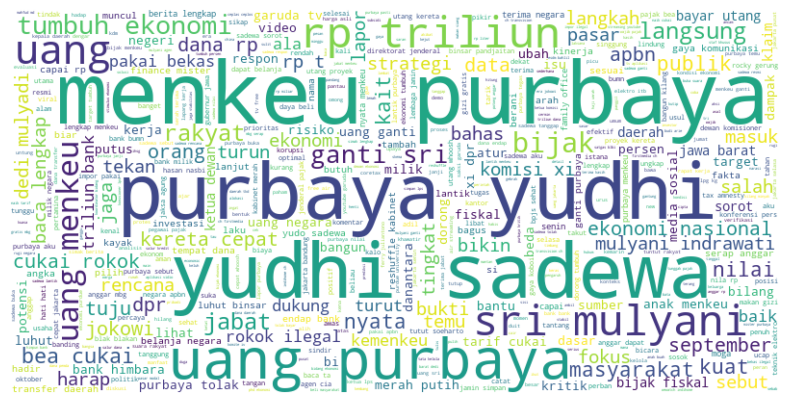

In [26]:
# WORDCLOUD 
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

text = ' '.join(df['stemming'].astype(str).tolist())

sw = set(STOPWORDS)
sw.update(
    [
        'pemerintah','presiden','wakil','prabowo','subianto','gibran',
        'rakabuming','raka','nih','program','indonesia','jalan','pimpin',
        'ri','menteri','hasil'
    ]
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    contour_width=1,
    contour_color='steelblue',
    colormap='viridis',
    stopwords=sw,
    max_words=500,
    random_state=42
).generate(text)

plt.figure(figsize=(8,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout()
plt.show()

In [27]:
# SIMPAN HASIL
df.to_csv(file_name, index=False, encoding="utf-8")